# 🏏 IPL Final Score Prediction Using Machine Learning

### Domain: Sports Analytics
### Problem Type: Regression

**Objective:**  
To predict the final score of an IPL innings using historical ball-by-ball cricket data and Machine Learning techniques.

**Algorithms Used:**
1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

## 2. Problem Statement

Predicting the final score of a cricket innings is an important problem in sports analytics.
The final score depends on several factors such as the current score, number of overs completed,
wickets lost, current run rate, batting team, bowling team, venue, and recent scoring performance.

The objective of this project is to develop a Machine Learning model that can predict the
expected final score of an IPL innings based on its current match situation.

The project uses historical IPL ball-by-ball data to create meaningful features and train
regression models for final score prediction.

## 3. Objectives

1. To understand and analyze historical IPL ball-by-ball data.
2. To clean and preprocess the cricket dataset.
3. To perform Exploratory Data Analysis (EDA).
4. To engineer useful features from ball-by-ball data.
5. To create a dataset suitable for final score prediction.
6. To train multiple Machine Learning regression models.
7. To compare Linear Regression, Decision Tree Regression, and Random Forest Regression.
8. To evaluate models using MAE, MSE, RMSE, and R² Score.
9. To identify the best-performing model.
10. To predict the final score of an IPL innings from its current match situation.

In [1]:
# ============================================
# 4. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# 5. LOAD DATASET
# ============================================

from google.colab import files

uploaded = files.upload()

Saving IPL_ball_by_ball_updated.csv to IPL_ball_by_ball_updated (1).csv


In [3]:
# Read uploaded CSV file

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# ============================================
# 6. DATASET OVERVIEW
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nFirst 5 Rows:")
display(df.head())

print("\nLast 5 Rows:")
display(df.tail())

Dataset Shape:
(243815, 22)

Number of Rows: 243815
Number of Columns: 22

First 5 Rows:


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Last 5 Rows:


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
243810,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.2,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,MM Sharma,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243811,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.3,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,MM Sharma,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243812,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.4,Chennai Super Kings,Gujarat Titans,S Dube,RA Jadeja,MM Sharma,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243813,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.5,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,MM Sharma,6,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
243814,1370353,2023,2023-05-29,"Narendra Modi Stadium, Ahmedabad",2,14.6,Chennai Super Kings,Gujarat Titans,RA Jadeja,S Dube,MM Sharma,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243815 entries, 0 to 243814
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   match_id                243815 non-null  int64  
 1   season                  243815 non-null  int64  
 2   start_date              243815 non-null  object 
 3   venue                   243815 non-null  object 
 4   innings                 243815 non-null  int64  
 5   ball                    243815 non-null  float64
 6   batting_team            243815 non-null  object 
 7   bowling_team            243815 non-null  object 
 8   striker                 243815 non-null  object 
 9   non_striker             243815 non-null  object 
 10  bowler                  243815 non-null  object 
 11  runs_off_bat            243815 non-null  int64  
 12  extras                  243815 non-null  int64  
 13  wides                   7652 non-null    float64
 14 

Statistical Summary

In [6]:
print("Statistical Summary:")
display(df.describe(include='all').T)

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
match_id,243815.0,NaN,NaN,NaN,870732.635999,353236.221562,335982.0,548316.0,829819.0,1216507.0,1370353.0
season,243815.0,NaN,NaN,NaN,2015.611119,4.650281,2008.0,2012.0,2015.0,2020.0,2023.0
start_date,243815,762,2020-10-18,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
venue,243815,56,Eden Gardens,17988,NaN,NaN,NaN,NaN,NaN,NaN,NaN
innings,243815.0,NaN,NaN,NaN,1.483781,0.502855,1.0,1.0,1.0,2.0,6.0
ball,243815.0,NaN,NaN,NaN,9.557662,5.686347,0.1,4.5,9.4,14.4,19.9
batting_team,243815,18,Mumbai Indians,29750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bowling_team,243815,18,Mumbai Indians,29799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
striker,243815,637,V Kohli,5739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
non_striker,243815,626,S Dhawan,5836,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Understanding

In [7]:
# ============================================
# 7. DATA UNDERSTANDING
# ============================================

print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nUnique Values in Important Columns:")

print("Seasons:", df['season'].nunique())
print("Matches:", df['match_id'].nunique())
print("Venues:", df['venue'].nunique())
print("Batting Teams:", df['batting_team'].nunique())
print("Bowling Teams:", df['bowling_team'].nunique())
print("Innings:", sorted(df['innings'].unique()))

Column Names:
['match_id', 'season', 'start_date', 'venue', 'innings', 'ball', 'batting_team', 'bowling_team', 'striker', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed']

Data Types:


,0
match_id,int64
season,int64
start_date,object
venue,object
innings,int64
ball,float64
batting_team,object
bowling_team,object
striker,object
non_striker,object



Unique Values in Important Columns:
Seasons: 16
Matches: 1024
Venues: 56
Batting Teams: 18
Bowling Teams: 18
Innings: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [8]:
print("Batting Teams:")
print(sorted(df['batting_team'].dropna().unique()))

print("\nBowling Teams:")
print(sorted(df['bowling_team'].dropna().unique()))

Batting Teams:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']

Bowling Teams:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


In [9]:
# ============================================
# 8. DATA CLEANING
# ============================================

# Create a copy
data = df.copy()

# Convert date column
data['start_date'] = pd.to_datetime(
    data['start_date'],
    errors='coerce'
)

# Convert numerical columns to numeric
numeric_columns = [
    'runs_off_bat',
    'extras',
    'wides',
    'noballs',
    'byes',
    'legbyes',
    'penalty'
]

for col in numeric_columns:
    data[col] = pd.to_numeric(
        data[col],
        errors='coerce'
    )

# Replace missing numerical delivery values with 0
for col in numeric_columns:
    data[col] = data[col].fillna(0)

# Remove exact duplicate rows
before_duplicates = len(data)

data = data.drop_duplicates()

after_duplicates = len(data)

print("Rows before removing duplicates:", before_duplicates)
print("Rows after removing duplicates:", after_duplicates)
print("Duplicates removed:", before_duplicates - after_duplicates)

Rows before removing duplicates: 243815
Rows after removing duplicates: 243815
Duplicates removed: 0


In [10]:
# ============================================
# 9. MISSING VALUE ANALYSIS
# ============================================

missing_values = data.isnull().sum()

missing_percentage = (
    data.isnull().sum() / len(data) * 100
).round(2)

missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

display(
    missing_table[
        missing_table['Missing Values'] > 0
    ].sort_values(
        'Missing Values',
        ascending=False
    )
)

,Missing Values,Missing Percentage
other_player_dismissed,243815,100.00
other_wicket_type,243815,100.00
player_dismissed,231748,95.05
wicket_type,231748,95.05


### Missing Value Interpretation

Missing values in columns such as `wicket_type` and `player_dismissed` are expected in
ball-by-ball cricket data because most deliveries do not result in a wicket.

Similarly, columns such as `wides`, `noballs`, `byes`, `legbyes`, and `penalty` can be
empty when that particular type of extra did not occur.

For numerical run-related columns, missing values are replaced with 0 because the absence
of a value indicates that no runs/extras of that type occurred on that delivery.

Categorical columns such as wicket-related fields will be handled appropriately during
feature engineering rather than deleting valid cricket deliveries.

In [11]:
# ============================================
# 10. FEATURE ENGINEERING
# ============================================

# Total runs scored on each delivery
data['total_runs'] = (
    data['runs_off_bat'] +
    data['extras']
)

# Extract over number from ball column
# Example: 0.1 -> over 0
#          5.3 -> over 5
data['over_number'] = (
    data['ball']
    .astype(str)
    .str.split('.')
    .str[0]
    .astype(int)
)

# Identify whether a wicket occurred
data['is_wicket'] = (
    data['player_dismissed']
    .notna()
    .astype(int)
)

print("Feature engineering started.")

display(
    data[
        [
            'match_id',
            'innings',
            'over_number',
            'batting_team',
            'bowling_team',
            'runs_off_bat',
            'extras',
            'total_runs',
            'is_wicket'
        ]
    ].head(10)
)

Feature engineering started.


,match_id,innings,over_number,batting_team,bowling_team,runs_off_bat,extras,total_runs,is_wicket
0,335982,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,1,0
1,335982,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,0
2,335982,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,1,0
3,335982,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,0
4,335982,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,0
5,335982,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,0
6,335982,1,0,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,1,0
7,335982,1,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,0,0,0
8,335982,1,1,Kolkata Knight Riders,Royal Challengers Bangalore,4,0,4,0
9,335982,1,1,Kolkata Knight Riders,Royal Challengers Bangalore,4,0,4,0


In [12]:
# ============================================
# 11. CREATE FINAL SCORE
# ============================================

# Calculate final score for each match and innings
final_scores = (
    data
    .groupby(['match_id', 'innings'])['total_runs']
    .sum()
    .reset_index()
)

final_scores.rename(
    columns={'total_runs': 'final_score'},
    inplace=True
)

print("Final score calculated successfully.")

display(final_scores.head(10))

Final score calculated successfully.


,match_id,innings,final_score
0,335982,1,222
1,335982,2,82
2,335983,1,240
3,335983,2,207
4,335984,1,129
5,335984,2,132
6,335985,1,165
7,335985,2,166
8,335986,1,110
9,335986,2,112


In [13]:
# Merge final score back into the dataset

data = data.merge(
    final_scores,
    on=['match_id', 'innings'],
    how='left'
)

display(
    data[
        [
            'match_id',
            'innings',
            'total_runs',
            'final_score'
        ]
    ].head(10)
)

,match_id,innings,total_runs,final_score
0,335982,1,1,222
1,335982,1,0,222
2,335982,1,1,222
3,335982,1,0,222
4,335982,1,0,222
5,335982,1,0,222
6,335982,1,1,222
7,335982,1,0,222
8,335982,1,4,222
9,335982,1,4,222


In [14]:
# ============================================
# 12. CREATE PREDICTION DATASET
# ============================================

# Keep only regular first and second innings
data_regular = data[
    data['innings'].isin([1, 2])
].copy()

# Sort data properly
data_regular = data_regular.sort_values(
    ['match_id', 'innings', 'over_number', 'ball']
)

# Group by match and innings
grouped = data_regular.groupby(
    ['match_id', 'innings'],
    sort=False
)

# Cumulative score
data_regular['current_score'] = (
    grouped['total_runs'].cumsum()
)

# Cumulative wickets
data_regular['wickets_lost'] = (
    grouped['is_wicket'].cumsum()
)

# Limit wickets to maximum 10
data_regular['wickets_lost'] = (
    data_regular['wickets_lost'].clip(upper=10)
)

In [15]:
# Calculate total runs and wickets per over

over_data = (
    data_regular
    .groupby(
        [
            'match_id',
            'innings',
            'over_number'
        ]
    )
    .agg(
        over_runs=('total_runs', 'sum'),
        over_wickets=('is_wicket', 'sum')
    )
    .reset_index()
)

display(over_data.head())

,match_id,innings,over_number,over_runs,over_wickets
0,335982,1,0,3,0
1,335982,1,1,18,0
2,335982,1,2,6,0
3,335982,1,3,23,0
4,335982,1,4,10,0


In [16]:
# Last 5 overs runs and wickets

over_data['last_5_over_runs'] = (
    over_data
    .groupby(['match_id', 'innings'])['over_runs']
    .transform(
        lambda x: x.rolling(
            window=5,
            min_periods=1
        ).sum()
    )
)

over_data['last_5_over_wickets'] = (
    over_data
    .groupby(['match_id', 'innings'])['over_wickets']
    .transform(
        lambda x: x.rolling(
            window=5,
            min_periods=1
        ).sum()
    )
)

In [17]:
# Select prediction points:
# End of 5th, 10th and 15th over

prediction_points = data_regular[
    data_regular['over_number'].isin([4, 9, 14])
].copy()

# Keep the final delivery of each selected over
prediction_points = (
    prediction_points
    .sort_values(
        [
            'match_id',
            'innings',
            'over_number',
            'ball'
        ]
    )
    .groupby(
        [
            'match_id',
            'innings',
            'over_number'
        ],
        as_index=False
    )
    .tail(1)
)

In [18]:
prediction_points = prediction_points.merge(
    over_data[
        [
            'match_id',
            'innings',
            'over_number',
            'last_5_over_runs',
            'last_5_over_wickets'
        ]
    ],
    on=[
        'match_id',
        'innings',
        'over_number'
    ],
    how='left'
)

In [19]:
# Number of completed overs
prediction_points['overs_completed'] = (
    prediction_points['over_number'] + 1
)

# Current run rate
prediction_points['current_run_rate'] = (
    prediction_points['current_score'] /
    prediction_points['overs_completed']
)

# Select final ML columns
ml_data = prediction_points[
    [
        'match_id',
        'season',
        'venue',
        'batting_team',
        'bowling_team',
        'overs_completed',
        'current_score',
        'wickets_lost',
        'current_run_rate',
        'last_5_over_runs',
        'last_5_over_wickets',
        'final_score'
    ]
].copy()

# Remove rows without target
ml_data = ml_data.dropna(
    subset=['final_score']
)

print("Final ML Dataset Shape:")
print(ml_data.shape)

display(ml_data.head(10))

Final ML Dataset Shape:
(6038, 12)


,match_id,season,venue,batting_team,bowling_team,overs_completed,current_score,wickets_lost,current_run_rate,last_5_over_runs,last_5_over_wickets,final_score
0,335982,2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,5,60,0,12.000000,60.0,0.0,222
1,335982,2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,10,87,1,8.700000,27.0,1.0,222
2,335982,2008,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,15,154,2,10.266667,67.0,1.0,222
3,335982,2008,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,5,24,3,4.800000,24.0,3.0,82
4,335982,2008,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,10,51,7,5.100000,27.0,4.0,82
5,335982,2008,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,15,81,9,5.400000,30.0,2.0,82
6,335983,2008,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,Kings XI Punjab,5,42,1,8.400000,42.0,1.0,240
7,335983,2008,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,Kings XI Punjab,10,88,3,8.800000,46.0,2.0,240
8,335983,2008,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,Kings XI Punjab,15,161,4,10.733333,73.0,1.0,240
9,335983,2008,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,5,47,0,9.400000,47.0,0.0,207


In [20]:
print("Missing values in ML dataset:")
display(ml_data.isnull().sum())

print("\nML Dataset Information:")
ml_data.info()

Missing values in ML dataset:


,0
match_id,0
season,0
venue,0
batting_team,0
bowling_team,0
overs_completed,0
current_score,0
wickets_lost,0
current_run_rate,0
last_5_over_runs,0



ML Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6038 entries, 0 to 6037
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             6038 non-null   int64  
 1   season               6038 non-null   int64  
 2   venue                6038 non-null   object 
 3   batting_team         6038 non-null   object 
 4   bowling_team         6038 non-null   object 
 5   overs_completed      6038 non-null   int64  
 6   current_score        6038 non-null   int64  
 7   wickets_lost         6038 non-null   int64  
 8   current_run_rate     6038 non-null   float64
 9   last_5_over_runs     6038 non-null   float64
 10  last_5_over_wickets  6038 non-null   float64
 11  final_score          6038 non-null   int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 566.2+ KB


# 13. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand patterns, distributions, relationships,
and trends in IPL scoring data before training the Machine Learning models.

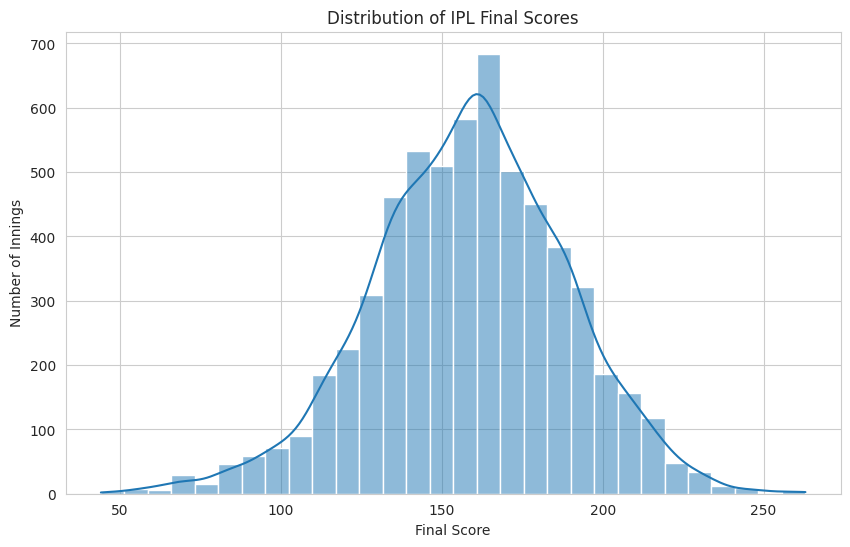

In [21]:
# ============================================
# VISUALIZATION 1
# DISTRIBUTION OF FINAL SCORES
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(
    ml_data['final_score'],
    bins=30,
    kde=True
)

plt.title('Distribution of IPL Final Scores')
plt.xlabel('Final Score')
plt.ylabel('Number of Innings')

plt.show()

### Insight

The histogram shows the distribution of final IPL innings scores.
It helps identify the most common scoring range and whether the score distribution
contains unusually low or high innings.

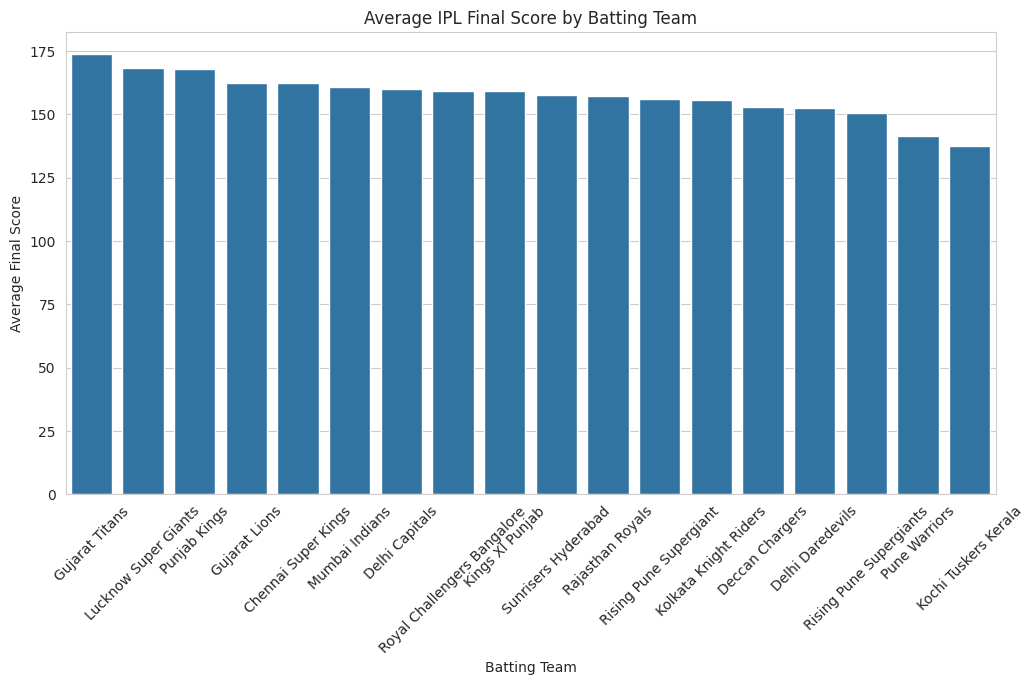

In [22]:
# ============================================
# VISUALIZATION 2
# AVERAGE FINAL SCORE BY TEAM
# ============================================

team_scores = (
    ml_data
    .groupby('batting_team')['final_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=team_scores.index,
    y=team_scores.values
)

plt.title('Average IPL Final Score by Batting Team')
plt.xlabel('Batting Team')
plt.ylabel('Average Final Score')

plt.xticks(rotation=45)

plt.show()

### Insight

Different teams show different historical scoring patterns.
The variation may be influenced by batting strength, team composition, playing style,
and historical performance.

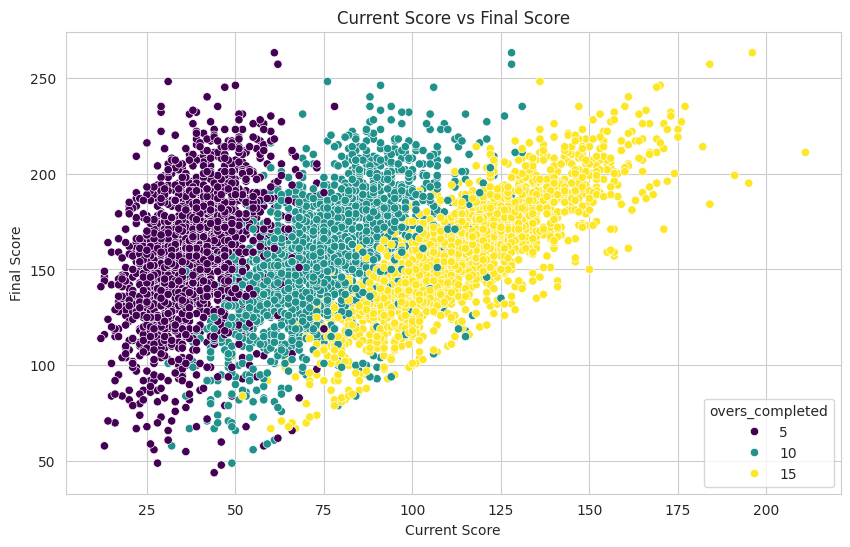

In [23]:
# ============================================
# VISUALIZATION 3
# CURRENT SCORE VS FINAL SCORE
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=ml_data,
    x='current_score',
    y='final_score',
    hue='overs_completed',
    palette='viridis'
)

plt.title('Current Score vs Final Score')
plt.xlabel('Current Score')
plt.ylabel('Final Score')

plt.show()

### Insight

There is a strong relationship between the score at the prediction point and the eventual
final score. Generally, innings with higher current scores tend to finish with higher final scores.

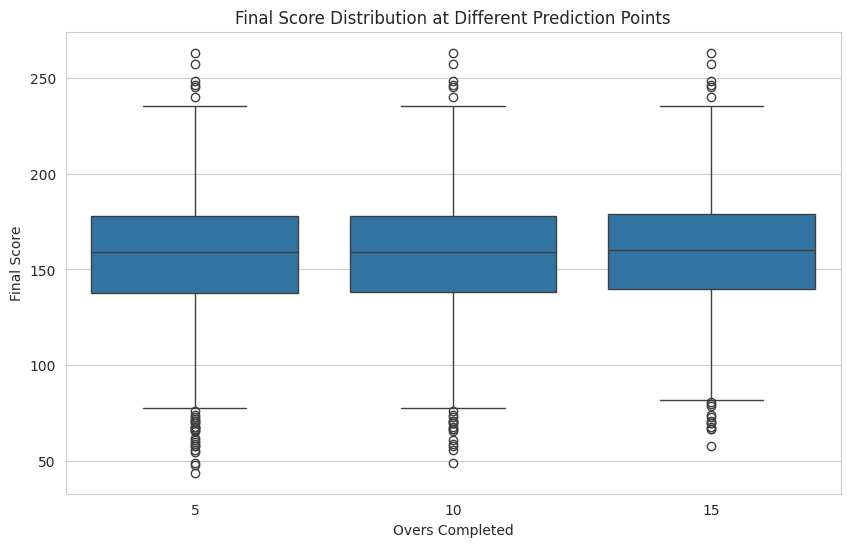

In [24]:
# ============================================
# VISUALIZATION 4
# OVERS COMPLETED VS FINAL SCORE
# ============================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=ml_data,
    x='overs_completed',
    y='final_score'
)

plt.title('Final Score Distribution at Different Prediction Points')
plt.xlabel('Overs Completed')
plt.ylabel('Final Score')

plt.show()

### Insight

The distribution of final scores changes as more overs are completed.
Prediction after 15 overs generally contains more information about the final score
than prediction after only 5 overs.

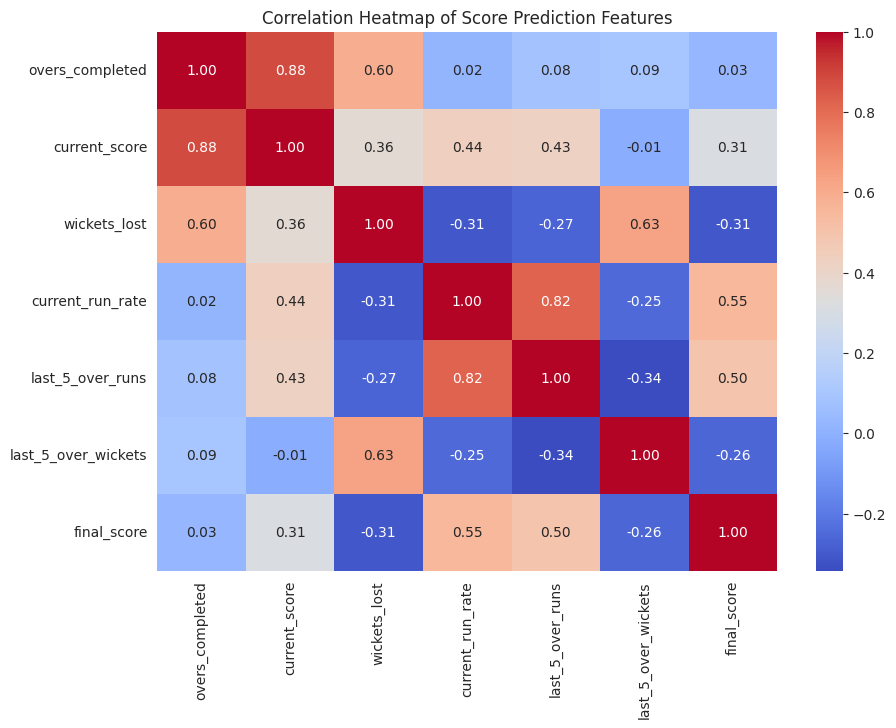

In [25]:
# ============================================
# VISUALIZATION 5
# CORRELATION HEATMAP
# ============================================

numeric_features = [
    'overs_completed',
    'current_score',
    'wickets_lost',
    'current_run_rate',
    'last_5_over_runs',
    'last_5_over_wickets',
    'final_score'
]

correlation_matrix = ml_data[
    numeric_features
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Score Prediction Features')

plt.show()

### Insight

The correlation heatmap helps identify relationships between numerical features and
the final score. Current score, overs completed, and recent scoring performance are
expected to have important relationships with the final score.

# 19. Feature Selection

The following features are selected for predicting the final score:

### Categorical Features
- Batting Team
- Bowling Team
- Venue

### Numerical Features
- Overs Completed
- Current Score
- Wickets Lost
- Current Run Rate
- Last 5 Over Runs
- Last 5 Over Wickets

### Target Variable
- Final Score

In [26]:
# ============================================
# 19. FEATURE SELECTION
# ============================================

features = [
    'batting_team',
    'bowling_team',
    'venue',
    'overs_completed',
    'current_score',
    'wickets_lost',
    'current_run_rate',
    'last_5_over_runs',
    'last_5_over_wickets'
]

target = 'final_score'

X = ml_data[features]
y = ml_data[target]

print("Features:")
print(features)

print("\nTarget:")
print(target)

print("\nFeature Dataset Shape:", X.shape)
print("Target Shape:", y.shape)

Features:
['batting_team', 'bowling_team', 'venue', 'overs_completed', 'current_score', 'wickets_lost', 'current_run_rate', 'last_5_over_runs', 'last_5_over_wickets']

Target:
final_score

Feature Dataset Shape: (6038, 9)
Target Shape: (6038,)


In [27]:
# ============================================
# 20. TRAIN-TEST SPLIT
# ============================================

print("Available seasons:")
print(sorted(ml_data['season'].unique()))

Available seasons:
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [28]:
# Time-based train-test split

train_data = ml_data[
    ml_data['season'] <= 2021
].copy()

test_data = ml_data[
    ml_data['season'] >= 2022
].copy()

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

print("Training records:", len(train_data))
print("Testing records:", len(test_data))

print("\nTraining seasons:")
print(sorted(train_data['season'].unique()))

print("\nTesting seasons:")
print(sorted(test_data['season'].unique()))

Training records: 5160
Testing records: 878

Training seasons:
[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Testing seasons:
[np.int64(2022), np.int64(2023)]


In [29]:
# ============================================
# PREPROCESSING
# ============================================

categorical_features = [
    'batting_team',
    'bowling_team',
    'venue'
]

numerical_features = [
    'overs_completed',
    'current_score',
    'wickets_lost',
    'current_run_rate',
    'last_5_over_runs',
    'last_5_over_wickets'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numerical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


# **Model 1 — Linear Regression**

In [30]:
# ============================================
# 21. LINEAR REGRESSION
# ============================================

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


# **Model 2 — Decision Tree Regression**

In [31]:
# ============================================
# 22. DECISION TREE REGRESSION
# ============================================

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            DecisionTreeRegressor(
                max_depth=10,
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

decision_tree_predictions = (
    decision_tree_model.predict(X_test)
)

print("Decision Tree Regression trained successfully!")

Decision Tree Regression trained successfully!


# **Model 3 — Random Forest Regression**

In [32]:
# ============================================
# 23. RANDOM FOREST REGRESSION
# ============================================

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                max_depth=15,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = (
    random_forest_model.predict(X_test)
)

print("Random Forest Regression trained successfully!")

Random Forest Regression trained successfully!


In [33]:
# ============================================
# 24. MODEL EVALUATION
# ============================================

def evaluate_model(
    model_name,
    y_true,
    predictions
):
    mae = mean_absolute_error(
        y_true,
        predictions
    )

    mse = mean_squared_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        predictions
    )

    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R² Score': r2
    }


linear_results = evaluate_model(
    'Linear Regression',
    y_test,
    linear_predictions
)

decision_tree_results = evaluate_model(
    'Decision Tree',
    y_test,
    decision_tree_predictions
)

random_forest_results = evaluate_model(
    'Random Forest',
    y_test,
    random_forest_predictions
)

print(linear_results)
print(decision_tree_results)
print(random_forest_results)

{'Model': 'Linear Regression', 'MAE': 19.38336107124935, 'MSE': 619.4133536158793, 'RMSE': np.float64(24.8880162651803), 'R² Score': 0.33226153731624486}
{'Model': 'Decision Tree', 'MAE': 20.4055514535855, 'MSE': 698.3584506755736, 'RMSE': np.float64(26.426472535614238), 'R² Score': 0.24715733760964576}
{'Model': 'Random Forest', 'MAE': 18.645942722429556, 'MSE': 576.776382016304, 'RMSE': np.float64(24.016169178624303), 'R² Score': 0.3782249407578938}


In [34]:
# ============================================
# 25. MODEL COMPARISON
# ============================================

results = pd.DataFrame([
    linear_results,
    decision_tree_results,
    random_forest_results
])

display(
    results.sort_values(
        by='RMSE'
    )
)

,Model,MAE,MSE,RMSE,R² Score
2,Random Forest,18.645943,576.776382,24.016169,0.378225
0,Linear Regression,19.383361,619.413354,24.888016,0.332262
1,Decision Tree,20.405551,698.358451,26.426473,0.247157


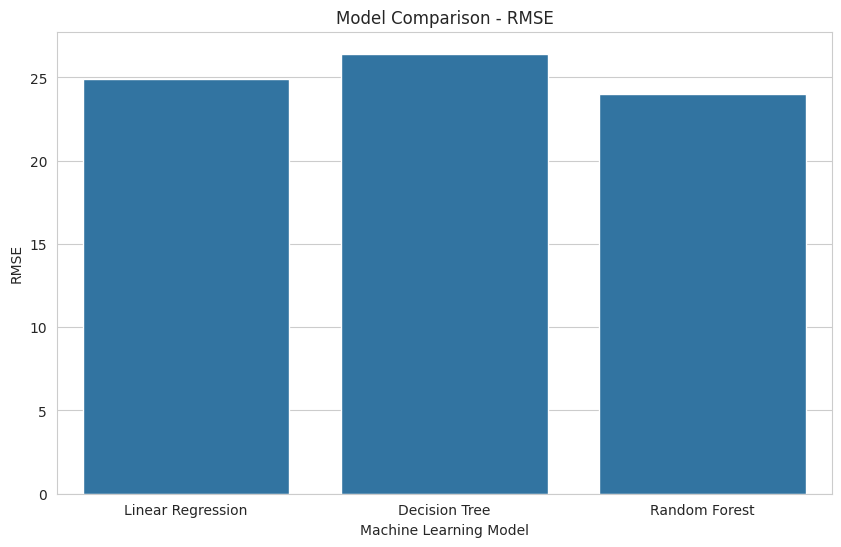

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x='Model',
    y='RMSE'
)

plt.title('Model Comparison - RMSE')
plt.xlabel('Machine Learning Model')
plt.ylabel('RMSE')

plt.show()

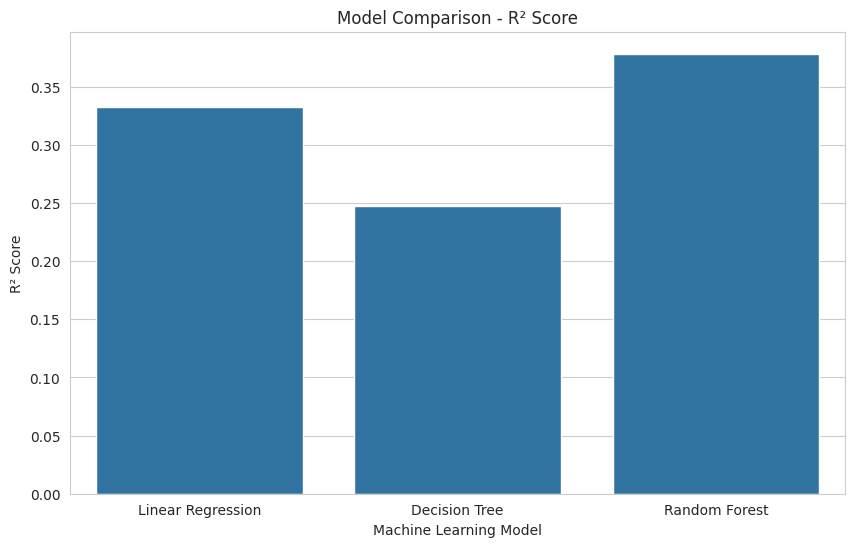

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x='Model',
    y='R² Score'
)

plt.title('Model Comparison - R² Score')
plt.xlabel('Machine Learning Model')
plt.ylabel('R² Score')

plt.show()

In [37]:
# ============================================
# 26. BEST MODEL
# ============================================

best_model_row = results.loc[
    results['RMSE'].idxmin()
]

print("Best Model:")
print(best_model_row['Model'])

print("\nBest Model Performance:")
print("MAE:", round(best_model_row['MAE'], 2))
print("MSE:", round(best_model_row['MSE'], 2))
print("RMSE:", round(best_model_row['RMSE'], 2))
print("R² Score:", round(best_model_row['R² Score'], 4))

Best Model:
Random Forest

Best Model Performance:
MAE: 18.65
MSE: 576.78
RMSE: 24.02
R² Score: 0.3782


In [38]:
# ============================================
# 27. SAMPLE PREDICTION
# ============================================

# Select Random Forest as the model to demonstrate prediction
# If another model performs better, replace this with that model.

best_model = random_forest_model

sample = X_test.iloc[[0]]

actual_score = y_test.iloc[0]

predicted_score = best_model.predict(
    sample
)[0]

print("Sample Match Situation:")
display(sample)

print("\nActual Final Score:",
      round(actual_score, 2))

print(
    "Predicted Final Score:",
    round(predicted_score, 2)
)

print(
    "Prediction Error:",
    round(
        abs(actual_score - predicted_score),
        2
    ),
    "runs"
)

Sample Match Situation:


,batting_team,bowling_team,venue,overs_completed,current_score,wickets_lost,current_run_rate,last_5_over_runs,last_5_over_wickets
5160,Chennai Super Kings,Kolkata Knight Riders,"Wankhede Stadium, Mumbai",5,29,2,5.8,29.0,2.0



Actual Final Score: 131
Predicted Final Score: 149.08
Prediction Error: 18.08 runs


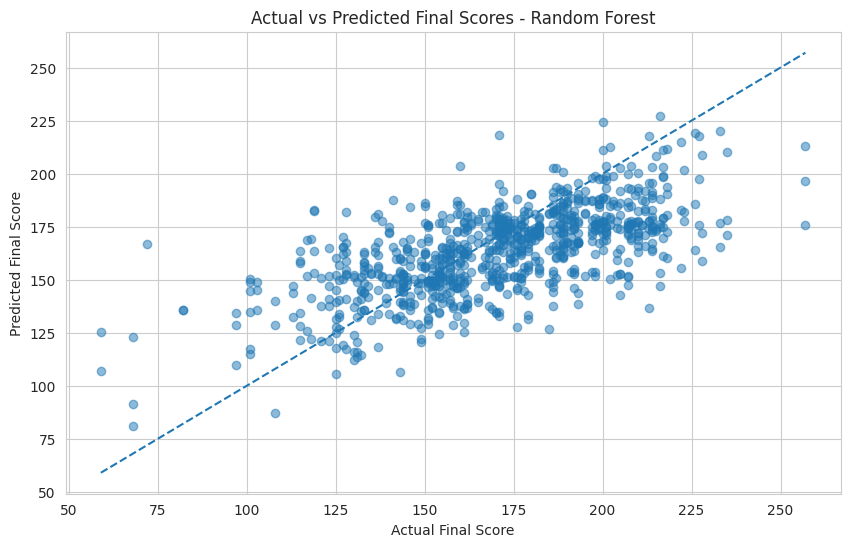

In [39]:
# ============================================
# ACTUAL VS PREDICTED SCORES
# ============================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    random_forest_predictions,
    alpha=0.5
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    random_forest_predictions.min()
)

max_value = max(
    y_test.max(),
    random_forest_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')

plt.title(
    'Actual vs Predicted Final Scores - Random Forest'
)

plt.show()

### Interpretation

Points closer to the diagonal line represent more accurate predictions.
A model with good predictive performance should have most of its predictions
close to the actual final scores.

# 28. Conclusion

This project developed a Machine Learning-based system for predicting the final score
of an IPL cricket innings.

Historical IPL ball-by-ball data was cleaned and transformed into meaningful features
such as current score, overs completed, wickets lost, current run rate, and recent
scoring performance.

Three regression algorithms were implemented:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE),
Root Mean Squared Error (RMSE), and R² Score.

Based on the evaluation results, the model with the lowest RMSE and strongest R² Score
was selected as the best-performing model.

The project demonstrates how Machine Learning can be applied to sports analytics to
estimate the expected final score of a cricket innings from its current match situation.

# 29. Limitations

1. The prediction is based mainly on historical IPL data.
2. Player-specific factors such as injuries and current form are not fully considered.
3. Weather conditions are not included.
4. Pitch conditions are not directly represented.
5. Real-time changes in player performance cannot be perfectly captured.
6. The model may perform differently for matches involving teams or venues with limited historical data.
7. The prediction is an estimate and cannot account for unpredictable events during a cricket match.

# 30. Future Scope

The project can be improved in several ways:

1. Add player-level performance features.
2. Include batsman and bowler statistics.
3. Include weather and pitch conditions.
4. Include toss information.
5. Include recent team performance.
6. Use real-time live match data.
7. Experiment with advanced models such as XGBoost.
8. Develop a web application using Flask or Streamlit.
9. Provide a predicted score range rather than only a single score.
10. Develop a real-time IPL score prediction dashboard.

In [ ]:
# ============================================
# 31. SAVE TRAINED MODEL PIPELINE
# ============================================
import joblib

# Save the trained Random Forest Pipeline (Preprocessor + Regressor)
joblib.dump(random_forest_model, "random_forest_model.pkl")
print("Trained Random Forest Pipeline saved successfully as random_forest_model.pkl!")
